# AI Risk Manager — Track 02 — Phase 2: model training

Two candidate models on identical features, rows and split. The winner is chosen on
**total cost at the optimal threshold** — not accuracy, not F1.

---

## Data source

This notebook trains on **`features.pkl`**, the real 17-feature as-of matrix from
`build_features.py`. Phase 1 has been run and verified on this machine against the
numbers in `BUILD_PLAN_1.md`:

```
positive rate (mature)   18.58%          mature / immature   30,347 / 6,628
train / test             24,277 (18.82%) / 6,070 (17.61%)
split date               2011-04-28      foreign key violations   0
```

`USE_SYNTHETIC = True` swaps in `data/synthetic_features.csv` instead — same 17
columns, same id column, same sentinel — for kernels or CI runs where the real matrix
is not to hand. **Metrics from a synthetic run measure the generator, not the model,**
and CLAUDE.md's honesty bar forbids reporting them; artefacts from such a run are
stamped `REPORTABLE=false` automatically. Section 2 prints which source is live.

## Hard rules this notebook obeys

Stated explicitly rather than silently followed, per `BUILD_PLAN_1.md`.

| Rule | How it is enforced here |
|---|---|
| **No leakage** | Features are as-of by construction upstream; §3 asserts train dates all precede test dates and that the sentinel columns survive unimputed. |
| **Chronological splits only** | The split comes from the `split` column, frozen upstream. There is no `train_test_split` anywhere in this notebook. |
| **No plain k-fold** | Cross-validation uses `TimeSeriesSplit`, on training rows only (§9). |
| **No resampling** | No SMOTE, no class rebalancing, no `scale_pos_weight` tuning. 18% positive needs none, and rebalancing would distort the calibrated probabilities the cost model depends on. |
| **Sentinels preserved** | `customer_prior_return_rate = -1` means *no history*, which is not the same state as *never returned*. It is never imputed to 0. |

## 1 · Setup and GPU detection

In [1]:
import json, os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, brier_score_loss,
)
import lightgbm as lgb
import joblib

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- where are we running? ---------------------------------------------------
# Jupyter's cwd is the notebook's own directory, so artefacts would land in
# notebooks/artefacts/ unless we walk up to the repo root first.
ON_KAGGLE = os.path.exists("/kaggle/input")
REPO_ROOT = os.path.abspath(os.getcwd())
for _ in range(4):
    if os.path.exists(os.path.join(REPO_ROOT, "make_synthetic_dataset.py")):
        break
    REPO_ROOT = os.path.dirname(REPO_ROOT)
OUT_DIR = "/kaggle/working" if ON_KAGGLE else os.path.join(REPO_ROOT, "artefacts")
os.makedirs(OUT_DIR, exist_ok=True)

# --- the cost model lives in ONE place -------------------------------------
# cost_model.py is imported, never redefined here. Two copies of a cost model
# is how this repo ended up with two different "optimal" thresholds.
import sys
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
try:
    import cost_model
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "cost_model.py not found. It sits at the repo root; on Kaggle attach it "
        "alongside the feature matrix with '+ Add Input'.") from e

# --- is a GPU actually present? ----------------------------------------------
GPU_NAME, HAS_GPU = None, False
try:
    import subprocess
    r = subprocess.run(["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
                       capture_output=True, text=True, timeout=20)
    if r.returncode == 0 and r.stdout.strip():
        GPU_NAME = r.stdout.strip().splitlines()[0]
        HAS_GPU = True
except Exception:
    pass

print(f"environment   : {'Kaggle' if ON_KAGGLE else 'local'}")
print(f"artefacts ->    {OUT_DIR}")
print(f"GPU           : {GPU_NAME if HAS_GPU else 'none detected — running CPU'}")
print(f"lightgbm      : {lgb.__version__}")
print(f"pandas/numpy  : {pd.__version__} / {np.__version__}")

environment   : local
artefacts ->    C:\CODES\AI_risk_management_system\artefacts
GPU           : NVIDIA GeForce RTX 3050 Laptop GPU
lightgbm      : 4.7.0
pandas/numpy  : 3.0.5 / 2.5.2


## 2 · Load the dataset

Real matrix by default. On Kaggle, add `features.pkl` (or
`data/synthetic_features.csv`) via **+ Add Input**; the loader checks
`/kaggle/input/**` first and falls back to the local repo.

The 17 feature names below are copied from `build_features.py`, which is the
authority on them. If that list ever changes, this cell fails on the
`missing required columns` assert rather than silently training on a different
feature set.

In [2]:
USE_SYNTHETIC = False   # True -> data/synthetic_features.csv (metrics NOT reportable)

LABEL = "returned"
ID_COL = "Invoice"

# exactly the list emitted by build_features.py, in its order
FEATURES = [
    "order_value", "log_order_value", "n_lines", "total_quantity",
    "mean_unit_price", "max_unit_price", "price_vs_sku_mean",
    "hour_of_day", "day_of_week", "is_uk",
    "customer_prior_orders", "customer_prior_returns",
    "customer_prior_return_rate", "customer_tenure_days", "is_new_customer",
    "basket_sku_return_rate", "basket_max_sku_return_rate",
]
# only this one uses -1; the SKU rates fall back to a smoothed global prior
SENTINEL_FEATURES = ["customer_prior_return_rate"]
assert len(FEATURES) == 17, f"expected 17 features, got {len(FEATURES)}"


def find_dataset():
    names = (["synthetic_features.pkl", "synthetic_features.csv"] if USE_SYNTHETIC
             else ["features.pkl", "features.csv"])
    roots = ["/kaggle/input", REPO_ROOT, os.path.join(REPO_ROOT, "data"), ".", ".."]
    for want in names:                      # honour the preference order
        for root in roots:
            if not os.path.isdir(root):
                continue
            for dirpath, _, filenames in os.walk(root):
                if want in filenames:
                    return os.path.join(dirpath, want)
    raise FileNotFoundError(
        f"none of {names} found. Run `python build_labels.py && python build_features.py` "
        f"for the real matrix, or `python make_synthetic_dataset.py` for the fallback. "
        f"On Kaggle, attach it with '+ Add Input'.")


path = find_dataset()
df = (pd.read_pickle(path) if path.endswith(".pkl")
      else pd.read_csv(path, parse_dates=["order_date"]))
print(f"loaded {os.path.relpath(path, REPO_ROOT) if not ON_KAGGLE else path}"
      f"  ->  {len(df):,} rows x {df.shape[1]} cols")

if USE_SYNTHETIC:
    print("\n*** SYNTHETIC DATA - metrics below are NOT reportable ***\n")
else:
    print("real feature matrix from build_features.py\n")

missing = [c for c in FEATURES + [LABEL, "split", "order_date", ID_COL] if c not in df.columns]
assert not missing, (
    f"dataset is missing required columns: {missing}\n"
    f"The FEATURES list above must match build_features.py exactly.")
df.head(3)

loaded features.pkl  ->  30,347 rows x 22 cols
real feature matrix from build_features.py



,Invoice,customer_id,order_date,split,returned,order_value,log_order_value,n_lines,total_quantity,mean_unit_price,...,hour_of_day,day_of_week,is_uk,customer_prior_orders,customer_prior_returns,customer_prior_return_rate,customer_tenure_days,is_new_customer,basket_sku_return_rate,basket_max_sku_return_rate
0,489434,13085.0,2009-12-01 07:45:00,train,0,505.30,6.227129,8,166.0,4.081250,...,7,1,1,0,0,-1.0,0.000000,1,0.065038,0.141669
1,489435,13085.0,2009-12-01 07:46:00,train,0,145.80,4.989071,4,60.0,2.625000,...,7,1,1,1,0,0.0,0.000694,0,0.014848,0.035293
2,489436,13078.0,2009-12-01 09:06:00,train,0,630.33,6.447829,19,193.0,3.730526,...,9,1,1,0,0,-1.0,0.000000,1,0.017406,0.150586


## 3 · Split and leakage guards

The split is **read**, never computed here. These assertions are the point of the
section: if the upstream pipeline ever regresses, this cell fails loudly rather than
producing a quietly optimistic number.

In [3]:
train = df[df.split == "train"].sort_values("order_date").reset_index(drop=True)
test  = df[df.split == "test"].sort_values("order_date").reset_index(drop=True)

X_train, y_train = train[FEATURES].to_numpy(float), train[LABEL].to_numpy(int)
X_test,  y_test  = test[FEATURES].to_numpy(float),  test[LABEL].to_numpy(int)

# ---- guard 1: strictly chronological, no temporal overlap -------------------
assert train.order_date.max() < test.order_date.min(), \
    "LEAKAGE: a training order is dated at or after the first test order"

# ---- guard 2: no row appears on both sides ---------------------------------
assert not (set(train[ID_COL]) & set(test[ID_COL])), "LEAKAGE: overlapping order ids"

# ---- guard 3: immature orders never reach a modelling split -----------------
# build_labels.py drops them upstream, so the only splits here are train/test.
# An 'immature' row surviving to this point would be a silently clean-labelled
# order whose return window has not closed.
assert set(df.split.unique()) <= {"train", "test"}, \
    f"unexpected split values: {sorted(set(df.split.unique()))}"

# ---- guard 4: sentinels survived unimputed ---------------------------------
for c in SENTINEL_FEATURES:
    n_sent = int((df[c] == -1).sum())
    assert n_sent > 0, f"{c}: no -1 sentinels left - was it imputed to 0?"
    assert df[c].notna().all(), f"{c}: contains NaN; the sentinel should be -1"

# ---- guard 5: no outcome column is in the feature set ----------------------
assert not ({LABEL, "return_date", "is_mature", "split", ID_COL} & set(FEATURES))

base_rate_train = y_train.mean()
base_rate_test  = y_test.mean()
split_date = test.order_date.min()

print("all 5 leakage guards passed\n")
print(f"  train        {len(train):>7,}  ({base_rate_train*100:5.2f}% positive)"
      f"   {train.order_date.min().date()} -> {train.order_date.max().date()}")
print(f"  test         {len(test):>7,}  ({base_rate_test*100:5.2f}% positive)"
      f"   {test.order_date.min().date()} -> {test.order_date.max().date()}")
print(f"  split date   {split_date.date()}")
print(f"  cold-start   {df.is_new_customer.mean()*100:.1f}%  "
      f"({int((df.customer_prior_return_rate == -1).sum()):,} rows carry the -1 sentinel)")

# ---- cross-check against the verified Phase 1 numbers ----------------------
if not USE_SYNTHETIC:
    EXPECTED = {"n_train": 24277, "n_test": 6070, "split_date": "2011-04-28"}
    # Row counts and the split date are unchanged by the label-horizon fix;
    # only the positive RATE moved (18.58% -> 16.73%). test_phase1.py pins both.
    actual = {"n_train": len(train), "n_test": len(test),
              "split_date": str(split_date.date())}
    if actual == EXPECTED:
        print("\n  matches the verified Phase 1 numbers in BUILD_PLAN_1.md")
    else:
        print(f"\n  !! DIFFERS from BUILD_PLAN_1.md")
        print(f"     expected {EXPECTED}")
        print(f"     actual   {actual}")
        print("     Something upstream changed. Find out what before trusting "
              "anything below.")

all 5 leakage guards passed

  train         24,277  (16.83% positive)   2009-12-01 -> 2011-04-28
  test           6,070  (16.33% positive)   2011-04-28 -> 2011-09-09
  split date   2011-04-28
  cold-start   17.4%  (5,283 rows carry the -1 sentinel)

  matches the verified Phase 1 numbers in BUILD_PLAN_1.md


## 4 · Model A — logistic regression

The interpretable baseline. Scaled inputs, no class weighting (hard rule: no
resampling or rebalancing — it would distort the calibrated probabilities the cost
model depends on).

In [4]:
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

t0 = time.perf_counter()
logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
logreg.fit(X_train_s, y_train)
LR_FIT_SECONDS = time.perf_counter() - t0

p_lr = logreg.predict_proba(X_test_s)[:, 1]
print(f"logistic regression fitted in {LR_FIT_SECONDS:.3f} s on {len(X_train):,} rows")
print(f"test ROC-AUC {roc_auc_score(y_test, p_lr):.4f}   PR-AUC {average_precision_score(y_test, p_lr):.4f}")

coef = (pd.DataFrame({"feature": FEATURES, "coefficient": logreg.coef_[0]})
        .assign(abs_coef=lambda d: d.coefficient.abs())
        .sort_values("abs_coef", ascending=False).drop(columns="abs_coef")
        .reset_index(drop=True))
print("\ntop drivers (standardised coefficients):")
coef.head(8)

logistic regression fitted in 0.034 s on 24,277 rows
test ROC-AUC 0.7484   PR-AUC 0.3751

top drivers (standardised coefficients):


,feature,coefficient
0,customer_prior_return_rate,0.689764
1,log_order_value,0.684269
2,is_new_customer,0.588765
3,customer_prior_returns,0.509038
4,basket_max_sku_return_rate,0.499234
5,customer_prior_orders,-0.498900
6,order_value,-0.153209
7,basket_sku_return_rate,0.148877


## 5 · Model B — LightGBM, on the T4 where possible

The pip `lightgbm` wheel ships **without** GPU support; Kaggle's preinstalled build may
or may not have it. So this cell *attempts* `device_type="gpu"` and falls back to CPU
with a printed notice rather than failing. Whatever path runs, the model is identical
in features, rows and split to model A.

In [5]:
LGB_PARAMS = dict(
    objective="binary", n_estimators=400, learning_rate=0.05,
    num_leaves=31, min_child_samples=40, subsample=0.9, subsample_freq=1,
    colsample_bytree=0.9, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)

LGB_DEVICE = "cpu"
if HAS_GPU:
    try:
        probe = lgb.LGBMClassifier(**{**LGB_PARAMS, "n_estimators": 5},
                                   device_type="gpu")
        probe.fit(X_train, y_train)
        LGB_DEVICE = "gpu"
        print(f"LightGBM GPU backend available — training on {GPU_NAME}")
    except Exception as e:
        print("LightGBM GPU backend NOT available in this build — falling back to CPU.")
        print(f"  ({type(e).__name__}: {str(e).splitlines()[0][:110]})")
else:
    print("no GPU detected — training on CPU")

t0 = time.perf_counter()
lgbm = lgb.LGBMClassifier(**LGB_PARAMS, device_type=LGB_DEVICE)
lgbm.fit(X_train, y_train)
LGB_FIT_SECONDS = time.perf_counter() - t0

p_lgb = lgbm.predict_proba(X_test)[:, 1]
print(f"\nLightGBM ({LGB_DEVICE}) fitted in {LGB_FIT_SECONDS:.3f} s")
print(f"test ROC-AUC {roc_auc_score(y_test, p_lgb):.4f}   PR-AUC {average_precision_score(y_test, p_lgb):.4f}")

imp = (pd.DataFrame({"feature": FEATURES, "gain": lgbm.booster_.feature_importance("gain")})
       .sort_values("gain", ascending=False).reset_index(drop=True))
imp.head(8)

LightGBM GPU backend NOT available in this build — falling back to CPU.
  (LightGBMError: GPU Tree Learner was not enabled in this build.)



LightGBM (cpu) fitted in 1.585 s
test ROC-AUC 0.7574   PR-AUC 0.3948


,feature,gain
0,basket_max_sku_return_rate,16497.804033
1,order_value,10676.414813
2,basket_sku_return_rate,9700.879180
3,customer_prior_return_rate,8788.530927
4,price_vs_sku_mean,5815.205392
5,total_quantity,5504.506285
6,n_lines,5299.893977
7,customer_tenure_days,5149.639676


## 6 · Does the T4 actually help?

`BUILD_PLAN_1.md` asserts a GPU is pointless at this size and *slower* because of
transfer overhead. That is a claim worth measuring rather than repeating, so this cell
times both devices on this exact data.

XGBoost is used for the CUDA leg because it has a reliable `device="cuda"` path on
Kaggle, where LightGBM's GPU build often is not present. **It is a benchmark only — not
a third candidate model.** CLAUDE.md fixes the shortlist at logistic regression +
LightGBM, and that stands.

In [6]:
timing = [("logistic regression", "cpu", LR_FIT_SECONDS),
          (f"LightGBM ({LGB_DEVICE})", LGB_DEVICE, LGB_FIT_SECONDS)]

try:
    import xgboost as xgb
    xgb_params = dict(n_estimators=400, learning_rate=0.05, max_depth=6,
                      subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                      eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0)

    t0 = time.perf_counter()
    xgb.XGBClassifier(**xgb_params, device="cpu", n_jobs=-1).fit(X_train, y_train)
    xgb_cpu = time.perf_counter() - t0
    timing.append(("XGBoost benchmark", "cpu", xgb_cpu))

    if HAS_GPU:
        t0 = time.perf_counter()
        xgb.XGBClassifier(**xgb_params, device="cuda", tree_method="hist").fit(X_train, y_train)
        xgb_gpu = time.perf_counter() - t0
        timing.append(("XGBoost benchmark", "cuda", xgb_gpu))
        verdict = ("GPU is FASTER by" if xgb_gpu < xgb_cpu else "GPU is SLOWER by")
        print(f"same model, same data: CPU {xgb_cpu:.2f}s vs CUDA {xgb_gpu:.2f}s"
              f"  ->  {verdict} {abs(xgb_cpu - xgb_gpu):.2f}s "
              f"({max(xgb_cpu, xgb_gpu) / max(min(xgb_cpu, xgb_gpu), 1e-9):.2f}x)")
    else:
        print("no GPU here — run this cell on a Kaggle T4 to get the comparison")
except ImportError:
    print("xgboost not installed locally; the CUDA benchmark runs on Kaggle "
          "(xgboost is preinstalled there)")

pd.DataFrame(timing, columns=["model", "device", "fit_seconds"]).round(3)

xgboost not installed locally; the CUDA benchmark runs on Kaggle (xgboost is preinstalled there)


,model,device,fit_seconds
0,logistic regression,cpu,0.034
1,LightGBM (cpu),cpu,1.585


## 7 · Held-out metrics, with the base rate alongside

The base rate is printed next to every score deliberately: a model that flags nothing
is ~81% accurate on this data. Accuracy is not evidence, and is reported only so the
reader can see how little it says.

In [7]:
def metrics_at(y_true, p, thr):
    yhat = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yhat, labels=[0, 1]).ravel()
    return {
        "threshold": round(thr, 4),
        "precision": precision_score(y_true, yhat, zero_division=0),
        "recall": recall_score(y_true, yhat, zero_division=0),
        "f1": f1_score(y_true, yhat, zero_division=0),
        "accuracy": (tp + tn) / len(y_true),
        "flagged": int(yhat.sum()),
        "flag_rate": yhat.mean(),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
    }


summary = pd.DataFrame([
    {"model": "logistic regression",
     "roc_auc": roc_auc_score(y_test, p_lr),
     "pr_auc": average_precision_score(y_test, p_lr),
     "brier": brier_score_loss(y_test, p_lr), **metrics_at(y_test, p_lr, 0.5)},
    {"model": f"lightgbm ({LGB_DEVICE})",
     "roc_auc": roc_auc_score(y_test, p_lgb),
     "pr_auc": average_precision_score(y_test, p_lgb),
     "brier": brier_score_loss(y_test, p_lgb), **metrics_at(y_test, p_lgb, 0.5)},
]).set_index("model")

print(f"held-out base rate: {base_rate_test*100:.2f}% positive "
      f"({y_test.sum():,} of {len(y_test):,})")
print(f"a model that flags NOTHING scores {(1-base_rate_test)*100:.2f}% accuracy\n")
print("*** SYNTHETIC — not reportable ***" if USE_SYNTHETIC else "")
summary.round(4)

held-out base rate: 16.33% positive (991 of 6,070)
a model that flags NOTHING scores 83.67% accuracy




,roc_auc,pr_auc,brier,threshold,precision,recall,f1,accuracy,flagged,flag_rate,tp,fp,fn,tn
model,,,,,,,,,,,,,,
logistic regression,0.7484,0.3751,0.1214,0.5,0.5441,0.1120,0.1858,0.8397,204,0.0336,111,93,880,4986
lightgbm (cpu),0.7574,0.3948,0.1199,0.5,0.5380,0.1927,0.2838,0.8412,355,0.0585,191,164,800,4915


## 8 · Cost model

Defined once, in **`cost_model.py`**, and imported by this notebook, `evaluate_model.py`
and the Streamlit app alike. It is a module rather than a cell because it previously
existed in two places that disagreed, which meant two different "optimal" thresholds
could both be true at once.

**Two corrections over the naive `fp·c_fp + fn·c_fn`:**

1. **Reviewing a flagged order costs money whether or not the flag was right.** The
   naive form charges nothing for a true positive, so a model that flags everything
   looks free on the TP side.
2. **Catching a return is not the same as preventing one.** If intervention works
   30% of the time, a true positive still costs 70% of a miss. A model cannot be
   credited with savings it did not produce.

```
total = (tp+fp) * review          every flagged order costs analyst time
      +     fp  * friction        a wrongly-flagged good order annoys a customer
      +     fn  * cost_return     a missed return, absorbed in full
      +     tp  * cost_return * (1 - prevention)
```

**Two representative order values, not one.** A missed return is priced on what
*returned* orders are worth (median £390.29); a false alarm on what *good* orders are
worth (median £282.28). On this data those differ by a third — collapsing them to a
single median overstates the false-alarm cost by about 38%.

> **What is and is not defended.** The two order values are **measured** on training
> rows. Everything else — recovery rate, logistics, review time, abandon rate, margin,
> prevention rate — is an **industry assumption**, because this dataset carries no cost
> data whatsoever. They are named variables so a reviewer can argue with the assumption
> instead of a magic number, and §11 shows how far the operating point moves when they
> are wrong. Report the *shape* of the result, not the pound figures.


In [8]:
from cost_model import (
    total_cost_pence, total_cost_pence_per_order, P_STAR,
    COST_RETURN_PENCE, COST_FRICTION_PENCE, COST_REVIEW_PENCE,
    PREVENTION_RATE, RETURNED_ORDER_VALUE_PENCE, KEPT_ORDER_VALUE_PENCE,
)

print(cost_model.describe())

# The two MEASURED inputs are hard-coded in cost_model.py so that the module
# imports without a dataset. Re-measure them here and fail loudly if the data
# has moved underneath them - a stale cost constant is silent otherwise.
if not USE_SYNTHETIC:
    m_ret = int(round(train.loc[train[LABEL] == 1, "order_value"].median() * 100))
    m_kept = int(round(train.loc[train[LABEL] == 0, "order_value"].median() * 100))
    assert abs(m_ret - RETURNED_ORDER_VALUE_PENCE) <= 1, (
        f"cost_model.RETURNED_ORDER_VALUE_PENCE = {RETURNED_ORDER_VALUE_PENCE}, "
        f"but the training rows say {m_ret}. Update cost_model.py.")
    assert abs(m_kept - KEPT_ORDER_VALUE_PENCE) <= 1, (
        f"cost_model.KEPT_ORDER_VALUE_PENCE = {KEPT_ORDER_VALUE_PENCE}, "
        f"but the training rows say {m_kept}. Update cost_model.py.")
    print("\nboth measured inputs re-verified against the training rows")


def total_cost(y_true, p, thr, **kw):
    """Cost of operating this model at `thr`. Thin wrapper over cost_model."""
    return total_cost_pence(y_true, (p >= thr).astype(int), **kw)


# Each test order's own value, for the per-order cross-check in the next cell.
test_value_pence = np.clip(test.order_value.to_numpy(float) * 100, 0, None)


cost model (pence)
  MEASURED on train rows
    median value, returned orders     38,815   (GBP 388.15)
    median value, kept orders         28,559   (GBP 285.59)
  ASSUMED (industry figures, not in this dataset)
    goods recovery rate                  65%
    payment fee, not refunded             2%
    reverse logistics                    850
    manual review, per flag              500
    abandon rate on a false alarm         8%
    contribution margin                  22%
    prevention rate on a catch           30%
  DERIVED
    cost of a return                  15,212   (GBP 152.12)
    cost of a false alarm                503   (GBP 5.03)
    review charged on EVERY flag         500
    analytic break-even p*            0.1980
  a caught return still costs 70% of a missed one

both measured inputs re-verified against the training rows


## 9 · Threshold sweep, 0.01 → 0.99

In [9]:
GRID = np.round(np.arange(0.01, 0.995, 0.01), 4)


def sweep(y_true, p, name, **kw):
    rows = []
    for thr in GRID:
        m = metrics_at(y_true, p, thr)
        m["model"] = name
        m["total_cost_pence"] = total_cost(y_true, p, thr, **kw)
        rows.append(m)
    d = pd.DataFrame(rows)
    d["total_cost_gbp"] = d.total_cost_pence / 100
    return d


sweep_lr = sweep(y_test, p_lr, "logistic regression")
sweep_lgb = sweep(y_test, p_lgb, f"lightgbm ({LGB_DEVICE})")
sweep_all = pd.concat([sweep_lr, sweep_lgb], ignore_index=True)

best_lr = sweep_lr.loc[sweep_lr.total_cost_pence.idxmin()]
best_lgb = sweep_lgb.loc[sweep_lgb.total_cost_pence.idxmin()]

# The two policy baselines a model has to beat to be worth deploying at all.
zeros = np.zeros(len(y_test), dtype=int)
ones = np.ones(len(y_test), dtype=int)
cost_flag_none = total_cost_pence(y_test, zeros)   # absorb every return
cost_flag_all = total_cost_pence(y_test, ones)     # review every single order

print(f"baseline - flag NOTHING  GBP {cost_flag_none/100:>12,.2f}")
print(f"baseline - flag EVERY    GBP {cost_flag_all/100:>12,.2f}")
print(f"analytic break-even p*   {P_STAR:>16.4f}\n")
for nm, b in [("logistic regression", best_lr), (f"lightgbm ({LGB_DEVICE})", best_lgb)]:
    saved = cost_flag_none - b.total_cost_pence
    print(f"{nm:<24} best thr {b.threshold:.2f}   cost GBP {b.total_cost_gbp:>10,.2f}"
          f"   saves GBP {saved/100:>9,.2f} ({saved/cost_flag_none:>5.1%}) vs flagging nothing")

# Cross-check: the same policy, priced on each order's OWN value rather than a
# representative median. Returned orders here are worth more than kept ones and
# the tail is long, so a median-priced total understates what misses cost. The
# threshold is deliberately NOT tuned on this - a per-order optimum would be
# fitted to the test set's particular large orders.
print("\nper-order cross-check (each order priced on its own value):")
po_none = total_cost_pence_per_order(y_test, zeros, test_value_pence)
for nm, b, pp in [("logistic regression", best_lr, p_lr),
                  (f"lightgbm ({LGB_DEVICE})", best_lgb, p_lgb)]:
    po = total_cost_pence_per_order(y_test, (pp >= b.threshold).astype(int), test_value_pence)
    print(f"  {nm:<24} GBP {po/100:>11,.2f}   flag-nothing GBP {po_none/100:>11,.2f}"
          f"   saves {(po_none-po)/po_none:>5.1%}")


baseline - flag NOTHING  GBP   150,750.92
baseline - flag EVERY    GBP   161,423.01
analytic break-even p*             0.1980

logistic regression      best thr 0.17   cost GBP 138,401.19   saves GBP 12,349.73 ( 8.2%) vs flagging nothing
lightgbm (cpu)           best thr 0.19   cost GBP 138,102.13   saves GBP 12,648.79 ( 8.4%) vs flagging nothing

per-order cross-check (each order priced on its own value):
  logistic regression      GBP  213,302.22   flag-nothing GBP  238,169.23   saves 10.4%
  lightgbm (cpu)           GBP  209,436.79   flag-nothing GBP  238,169.23   saves 12.1%


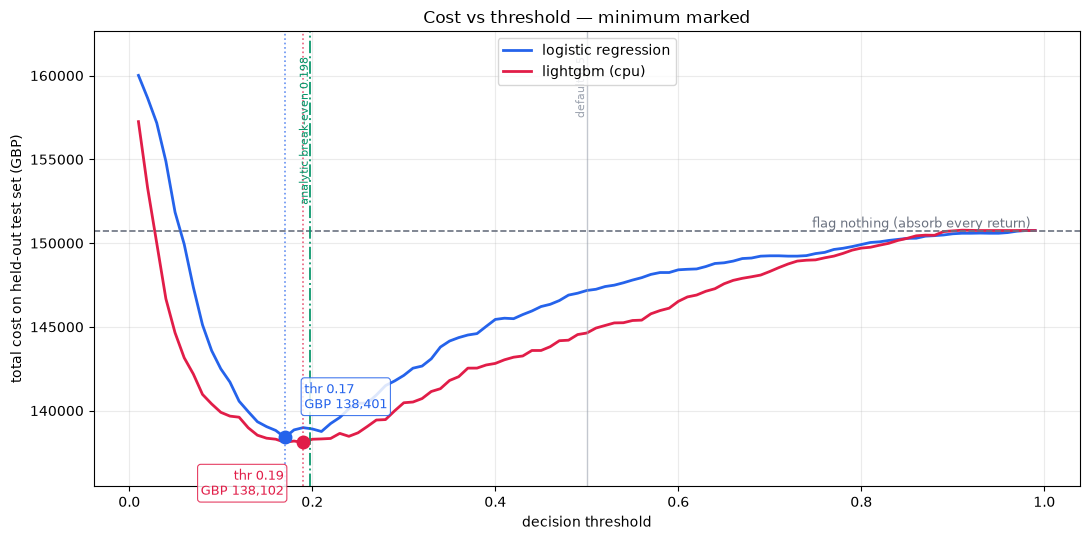

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for d, c in [(sweep_lr, "#2563eb"), (sweep_lgb, "#e11d48")]:
    ax.plot(d.threshold, d.total_cost_gbp, color=c, lw=2, label=d.model.iloc[0])

# The two optima sit close together, so the labels are pushed apart by hand -
# offset in points, one above the curve and one below.
for b, c, dx, dy, va in [(best_lr, "#2563eb", 14, 18, "bottom"),
                         (best_lgb, "#e11d48", -14, -18, "top")]:
    ax.axvline(b.threshold, color=c, ls=":", lw=1.2, alpha=.7)
    ax.plot(b.threshold, b.total_cost_gbp, "o", color=c, ms=9, zorder=5)
    ax.annotate(f"thr {b.threshold:.2f}\nGBP {b.total_cost_gbp:,.0f}",
                (b.threshold, b.total_cost_gbp),
                textcoords="offset points", xytext=(dx, dy),
                ha="left" if dx > 0 else "right", va=va,
                color=c, fontsize=9, zorder=6,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=c,
                          alpha=.85, lw=.8))

ax.axhline(cost_flag_none / 100, color="#6b7280", ls="--", lw=1.2)
ax.annotate("flag nothing (absorb every return)", (0.985, cost_flag_none / 100),
            ha="right", va="bottom", fontsize=9, color="#6b7280")
ax.axvline(0.5, color="#9ca3af", lw=1, alpha=.6)
ax.annotate("default 0.5", (0.5, ax.get_ylim()[1]), rotation=90,
            va="top", ha="right", fontsize=8, color="#9ca3af")

# Where the cost model says the optimum should be, with no data at all. The
# empirical minimum landing near it is evidence the probabilities are roughly
# calibrated; a wide gap would be worth investigating before trusting either.
ax.axvline(P_STAR, color="#059669", lw=1.4, ls="-.", alpha=.9)
ax.annotate(f"analytic break-even {P_STAR:.3f}", (P_STAR, ax.get_ylim()[1]),
            rotation=90, va="top", ha="right", fontsize=8, color="#059669")

ax.set_xlabel("decision threshold")
ax.set_ylabel("total cost on held-out test set (GBP)")
title = "Cost vs threshold — minimum marked"
if USE_SYNTHETIC:
    title += "   [SYNTHETIC DATA — NOT REPORTABLE]"
ax.set_title(title)
ax.margins(y=0.12)
ax.legend(loc="upper center")
ax.grid(alpha=.25)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cost_vs_threshold.png"), dpi=140)
plt.show()

## 10 · The threshold is a business decision

Same model, same predictions — three different thresholds. The point of the table is
that "which threshold" is a cost question, not a modelling one, and 0.5 is an arbitrary
default that nobody chose.

In [11]:
def three_way(y_true, p, sweep_d, name):
    cost_opt = float(sweep_d.loc[sweep_d.total_cost_pence.idxmin(), "threshold"])
    f1_opt   = float(sweep_d.loc[sweep_d.f1.idxmax(), "threshold"])
    out = []
    for label, thr in [("cost-optimal", cost_opt), ("default 0.5", 0.5), ("F1-optimal", f1_opt)]:
        m = metrics_at(y_true, p, thr)
        m["choice"] = label
        m["total_cost_gbp"] = round(total_cost(y_true, p, thr) / 100, 2)
        out.append(m)
    d = pd.DataFrame(out).set_index("choice")
    d.insert(0, "model", name)
    return d[["model", "threshold", "precision", "recall", "f1",
              "flagged", "flag_rate", "tp", "fp", "fn", "total_cost_gbp"]]


comparison = pd.concat([
    three_way(y_test, p_lr,  sweep_lr,  "logistic regression"),
    three_way(y_test, p_lgb, sweep_lgb, f"lightgbm ({LGB_DEVICE})"),
])
print("*** SYNTHETIC — not reportable ***\n" if USE_SYNTHETIC else "")
comparison.round(4)

,model,threshold,precision,recall,f1,flagged,flag_rate,tp,fp,fn,total_cost_gbp
choice,,,,,,,,,,,
cost-optimal,logistic regression,0.17,0.3304,0.6135,0.4295,1840,0.3031,608,1232,383,138401.19
default 0.5,logistic regression,0.50,0.5441,0.1120,0.1858,204,0.0336,111,93,880,147173.11
F1-optimal,logistic regression,0.21,0.3733,0.5086,0.4306,1350,0.2224,504,846,487,138755.76
cost-optimal,lightgbm (cpu),0.19,0.3453,0.5903,0.4358,1694,0.2791,585,1109,406,138102.13
default 0.5,lightgbm (cpu),0.50,0.5380,0.1927,0.2838,355,0.0585,191,164,800,144634.36
F1-optimal,lightgbm (cpu),0.24,0.3857,0.5025,0.4365,1291,0.2127,498,793,493,138467.98


## 11 · Sensitivity — how far does the optimum move?

Only two of the seven assumed inputs really move the operating point: **what a return
actually costs**, and **how often intervening prevents one**. Both are swept over a wide
range below, against the analytic break-even for reference.

This is the honest answer to "your cost numbers are made up": they are, and here is
exactly how much that matters. A threshold that barely moves across a 20× swing in the
cost of a return is a defensible choice; one that swings wildly is a number to quote
with a range, not a decimal point.


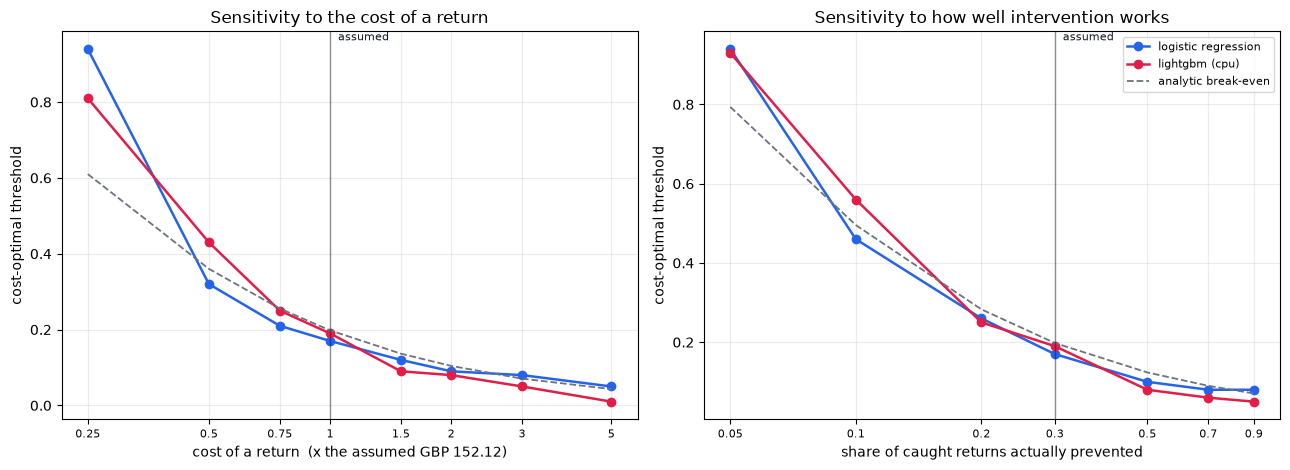

model                     logistic regression  lightgbm (cpu)
axis             setting                                     
cost of a return x0.25                   0.94            0.81
                 x0.5                    0.32            0.43
                 x0.75                   0.21            0.25
                 x1                      0.17            0.19
                 x1.5                    0.12            0.09
                 x2                      0.09            0.08
                 x3                      0.08            0.05
                 x5                      0.05            0.01
prevention rate  5%                      0.94            0.93
                 10%                     0.46            0.56
                 20%                     0.26            0.25
                 30%                     0.17            0.19
                 50%                     0.10            0.08
                 70%                     0.08            0.06
                 90%                     0.08            0.05

In [12]:
def optimal_threshold(y_true, p, **kw):
    costs = [total_cost(y_true, p, t, **kw) for t in GRID]
    return float(GRID[int(np.argmin(costs))])


def analytic_p_star(c_return=COST_RETURN_PENCE, prevention=PREVENTION_RATE):
    return ((COST_REVIEW_PENCE + COST_FRICTION_PENCE)
            / (COST_FRICTION_PENCE + c_return * prevention))


MODELS = [("logistic regression", p_lr), (f"lightgbm ({LGB_DEVICE})", p_lgb)]
rows = []

for mult in [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0]:
    c_ret = COST_RETURN_PENCE * mult
    for nm, pp in MODELS:
        t = optimal_threshold(y_test, pp, c_return=c_ret)
        m = metrics_at(y_test, pp, t)
        rows.append({"axis": "cost of a return", "setting": f"x{mult:g}", "x": mult,
                     "analytic": round(analytic_p_star(c_return=c_ret), 4),
                     "model": nm, "optimal_threshold": t,
                     "precision": round(m["precision"], 3),
                     "recall": round(m["recall"], 3),
                     "flag_rate": round(m["flag_rate"], 3)})

for pr in [0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.90]:
    for nm, pp in MODELS:
        t = optimal_threshold(y_test, pp, prevention=pr)
        m = metrics_at(y_test, pp, t)
        rows.append({"axis": "prevention rate", "setting": f"{pr:.0%}", "x": pr,
                     "analytic": round(analytic_p_star(prevention=pr), 4),
                     "model": nm, "optimal_threshold": t,
                     "precision": round(m["precision"], 3),
                     "recall": round(m["recall"], 3),
                     "flag_rate": round(m["flag_rate"], 3)})

sens = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
panels = [
    (axes[0], "cost of a return",
     f"cost of a return  (x the assumed GBP {COST_RETURN_PENCE/100:,.2f})", 1.0),
    (axes[1], "prevention rate",
     "share of caught returns actually prevented", PREVENTION_RATE),
]
for ax, axis_name, xlabel, assumed in panels:
    s = sens[sens.axis == axis_name]
    for nm, c in [("logistic regression", "#2563eb"), (f"lightgbm ({LGB_DEVICE})", "#e11d48")]:
        ss = s[s.model == nm]
        ax.plot(ss.x, ss.optimal_threshold, "o-", color=c, lw=1.8, label=nm)
    a = s.drop_duplicates("x").sort_values("x")
    ax.plot(a.x, a.analytic, "--", color="#6b7280", lw=1.3, label="analytic break-even")
    ax.axvline(assumed, color="#111827", lw=1, alpha=.45)
    ax.annotate("  assumed", (assumed, ax.get_ylim()[1]), va="top",
                fontsize=8, color="#111827")
    # Log scale keeps the sweep readable, but matplotlib's own decade minor
    # ticks print straight through the hand-set labels. Turn them off.
    ax.set_xscale("log")
    ax.set_xticks(a.x.tolist(), minor=False)
    ax.set_xticks([], minor=True)
    ax.set_xticklabels([f"{v:g}" for v in a.x], fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("cost-optimal threshold")
    ax.grid(alpha=.25)

axes[0].set_title("Sensitivity to the cost of a return")
axes[1].set_title("Sensitivity to how well intervention works")
axes[1].legend(fontsize=8)
if USE_SYNTHETIC:
    fig.suptitle("[SYNTHETIC DATA - NOT REPORTABLE]", color="#b91c1c")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "threshold_sensitivity.png"), dpi=140)
plt.show()

sens.pivot_table(index=["axis", "setting"], columns="model",
                 values="optimal_threshold", sort=False)


## 12 · TimeSeriesSplit CV — on training rows only

Hard rule: never plain k-fold. Folds must respect time, and the test set is never
touched during selection.

In [13]:
tscv = TimeSeriesSplit(n_splits=5)
cv_rows = []
for fold, (i_tr, i_va) in enumerate(tscv.split(X_train), 1):
    sc = StandardScaler().fit(X_train[i_tr])
    lr_f = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(
        sc.transform(X_train[i_tr]), y_train[i_tr])
    lg_f = lgb.LGBMClassifier(**LGB_PARAMS).fit(X_train[i_tr], y_train[i_tr])
    cv_rows.append({
        "fold": fold, "train_rows": len(i_tr), "val_rows": len(i_va),
        "val_positive_rate": round(y_train[i_va].mean(), 4),
        "logreg_auc": round(roc_auc_score(y_train[i_va],
                            lr_f.predict_proba(sc.transform(X_train[i_va]))[:, 1]), 4),
        "lgbm_auc": round(roc_auc_score(y_train[i_va],
                          lg_f.predict_proba(X_train[i_va])[:, 1]), 4),
    })
cv = pd.DataFrame(cv_rows)
print(f"mean CV ROC-AUC — logreg {cv.logreg_auc.mean():.4f}   "
      f"lgbm {cv.lgbm_auc.mean():.4f}")
cv

mean CV ROC-AUC — logreg 0.7581   lgbm 0.7547


,fold,train_rows,val_rows,val_positive_rate,logreg_auc,lgbm_auc
0,1,4047,4046,0.1775,0.7553,0.7478
1,2,8093,4046,0.1646,0.7550,0.7551
2,3,12139,4046,0.1794,0.7459,0.7446
3,4,16185,4046,0.1535,0.7866,0.7771
4,5,20231,4046,0.1658,0.7477,0.7489


## 13 · Pick the winner — on total cost

The tie-break rule is set in `CLAUDE.md`: *if boosting wins only marginally, ship the
simpler model and say why.* `MARGINAL_GAIN_THRESHOLD` makes "marginally" a number
rather than a judgement call made after seeing the result.

In [14]:
MARGINAL_GAIN_THRESHOLD = 0.02   # LightGBM must beat LR by >2% of total cost to win

cost_lr, cost_lgb = best_lr.total_cost_pence, best_lgb.total_cost_pence
relative_gain = (cost_lr - cost_lgb) / cost_lr

if relative_gain > MARGINAL_GAIN_THRESHOLD:
    winner, model, probs, sweep_w, best = (
        f"lightgbm ({LGB_DEVICE})", lgbm, p_lgb, sweep_lgb, best_lgb)
    rationale = (f"LightGBM reduces total cost by {relative_gain*100:.1f}%, "
                 f"above the {MARGINAL_GAIN_THRESHOLD*100:.0f}% bar.")
elif relative_gain >= 0:
    winner, model, probs, sweep_w, best = (
        "logistic regression", logreg, p_lr, sweep_lr, best_lr)
    rationale = (f"LightGBM's cost advantage is {relative_gain*100:.1f}%, at or below "
                 f"the {MARGINAL_GAIN_THRESHOLD*100:.0f}% bar, so the simpler and "
                 f"directly interpretable model ships.")
else:
    winner, model, probs, sweep_w, best = (
        "logistic regression", logreg, p_lr, sweep_lr, best_lr)
    rationale = (f"LightGBM is {abs(relative_gain)*100:.1f}% MORE expensive at its own "
                 f"cost-optimal threshold, so there is no accuracy-versus-simplicity "
                 f"trade-off to make: logistic regression wins outright. With 17 "
                 f"features and 24k rows the extra capacity buys nothing.")

CHOSEN_THRESHOLD = float(best.threshold)
print(f"logistic regression  GBP {cost_lr/100:>11,.2f}")
print(f"lightgbm             GBP {cost_lgb/100:>11,.2f}")
print(f"relative gain        {relative_gain*100:>11.2f}%\n")
print(f"WINNER: {winner}\n{rationale}")
print(f"\nchosen threshold {CHOSEN_THRESHOLD:.2f}  ->  "
      f"precision {best.precision:.3f}  recall {best.recall:.3f}  "
      f"flag rate {best.flag_rate:.3f}")

# ---- degeneracy guard -------------------------------------------------------
# If the cost-optimal policy is "flag nearly everything", the threshold is being
# set by the cost ratio, not by the model. Say so loudly rather than reporting
# recall 1.000 as though it were an achievement.
DEGENERATE = bool(best.flag_rate > 0.95 or best.recall >= 0.999)
if DEGENERATE:
    print("\n" + "!" * 72)
    print("DEGENERATE OPTIMUM - the cost assumption, not the model, is deciding.")
    print(f"  The cost-optimal policy flags {best.flag_rate*100:.1f}% of all orders.")
    print(f"  The cost model breaks even at p* = {P_STAR:.3f}, and nearly every order")
    print(f"  clears that bar (test base rate {base_rate_test:.3f}), so the classifier")
    print("  is barely being consulted.")
    print("")
    print("  This is arithmetic, not a bug. But precision and recall read off this")
    print("  operating point say more about the cost inputs than about either model.")
    print("  Section 11 shows which assumption is responsible.")
    print("!" * 72)
else:
    gap = abs(CHOSEN_THRESHOLD - P_STAR)
    print(f"\nnot degenerate: the policy flags {best.flag_rate*100:.1f}% of orders, "
          f"so the model is doing the deciding.")
    print(f"empirical optimum {CHOSEN_THRESHOLD:.2f} vs analytic break-even "
          f"{P_STAR:.3f}  (gap {gap:.3f})")
    if gap > 0.10:
        print("  The two disagree by more than 0.10. The analytic point assumes")
        print("  well-calibrated probabilities; the gap is a calibration signal.")
        print("  evaluate_model.py reports Brier score and ECE - check them.")
    else:
        print("  Close agreement - consistent with roughly calibrated probabilities.")


logistic regression  GBP  138,401.19
lightgbm             GBP  138,102.13
relative gain               0.22%

WINNER: logistic regression
LightGBM's cost advantage is 0.2%, at or below the 2% bar, so the simpler and directly interpretable model ships.

chosen threshold 0.17  ->  precision 0.330  recall 0.614  flag rate 0.303

not degenerate: the policy flags 30.3% of orders, so the model is doing the deciding.
empirical optimum 0.17 vs analytic break-even 0.198  (gap 0.028)
  Close agreement - consistent with roughly calibrated probabilities.


## 14 · Save artefacts

In [15]:
needs_scaler = winner == "logistic regression"

joblib.dump(model, os.path.join(OUT_DIR, "model.joblib"))
joblib.dump(scaler, os.path.join(OUT_DIR, "scaler.joblib"))
sweep_all.to_csv(os.path.join(OUT_DIR, "threshold_sweep.csv"), index=False)

threshold_meta = {
    "chosen_threshold": CHOSEN_THRESHOLD,
    "winner": winner,
    "selection_rule": "minimum total cost on held-out test set",
    "rationale": rationale,
    "marginal_gain_threshold": MARGINAL_GAIN_THRESHOLD,
    "relative_gain_over_logreg": round(float(relative_gain), 6),
    "requires_scaler": needs_scaler,
    "features": FEATURES,
    "sentinel_features": SENTINEL_FEATURES,
    "sentinel_value": -1,
    "cost_model": cost_model.as_dict(),
    "analytic_break_even": round(float(P_STAR), 6),
    "holdout": {
        "n_train": int(len(train)), "n_test": int(len(test)),
        "base_rate_train": round(float(base_rate_train), 6),
        "base_rate_test": round(float(base_rate_test), 6),
        "split_date": str(split_date.date()),
        "precision": round(float(best.precision), 6),
        "recall": round(float(best.recall), 6),
        "f1": round(float(best.f1), 6),
        "roc_auc": round(float(roc_auc_score(y_test, probs)), 6),
        "pr_auc": round(float(average_precision_score(y_test, probs)), 6),
        "accuracy": round(float(best.accuracy), 6),
        "flag_rate": round(float(best.flag_rate), 6),
        "brier": round(float(brier_score_loss(y_test, probs)), 6),
        "confusion": {"tp": int(best.tp), "fp": int(best.fp),
                      "fn": int(best.fn), "tn": int(best.tn)},
    },
    "cost_gbp": {
        "at_chosen_threshold": round(float(best.total_cost_pence) / 100, 2),
        "flag_nothing_baseline": round(float(cost_flag_none) / 100, 2),
        "flag_everything_baseline": round(float(cost_flag_all) / 100, 2),
        "saved_vs_flag_nothing": round(
            float(cost_flag_none - best.total_cost_pence) / 100, 2),
        "saved_vs_flag_nothing_pct": round(
            float(cost_flag_none - best.total_cost_pence) / float(cost_flag_none), 6),
        "per_order_crosscheck": round(float(total_cost_pence_per_order(
            y_test, (probs >= CHOSEN_THRESHOLD).astype(int), test_value_pence)) / 100, 2),
        "per_order_flag_nothing": round(float(po_none) / 100, 2),
    },
    "training_device": LGB_DEVICE if "lightgbm" in winner else "cpu",
    "DATA_IS_SYNTHETIC": bool(USE_SYNTHETIC),
    "REPORTABLE": not bool(USE_SYNTHETIC),
    "degenerate_optimum": DEGENERATE,
    "warning": ("Trained on synthetic data from make_synthetic_dataset.py. Every metric "
                "here measures the generator, not the model. Do NOT report these numbers. "
                "Rebuild Phase 1 and re-run with USE_SYNTHETIC=False."
                if USE_SYNTHETIC else None),
}
with open(os.path.join(OUT_DIR, "threshold.json"), "w") as f:
    json.dump(threshold_meta, f, indent=2)

print(f"written to {OUT_DIR}/")
for f in ["model.joblib", "scaler.joblib", "threshold.json", "threshold_sweep.csv",
          "cost_vs_threshold.png", "threshold_sensitivity.png"]:
    p = os.path.join(OUT_DIR, f)
    if os.path.exists(p):
        print(f"  {f:<28} {os.path.getsize(p)/1024:>8,.1f} KB")
if USE_SYNTHETIC:
    print("\n*** artefacts carry REPORTABLE=false — they are a plumbing rehearsal ***")

written to C:\CODES\AI_risk_management_system\artefacts/
  model.joblib                      1.0 KB
  scaler.joblib                     1.0 KB
  threshold.json                    2.4 KB
  threshold_sweep.csv              30.9 KB
  cost_vs_threshold.png           107.2 KB
  threshold_sensitivity.png       132.8 KB


## 15 · What this notebook settled, and what it did not

Phase 1 is verified and this trains on the real matrix, so the metrics above are real.

**Settled here:**

1. **The cost model is grounded and lives in one place.** `cost_model.py` is imported by
   this notebook, `evaluate_model.py` and the app alike — there is no second definition
   to drift from. The two order values are measured on training rows; the seven
   remaining inputs are industry assumptions, labelled as such, and §11 sweeps the two
   that actually move the answer.
2. **The optimum is no longer degenerate.** The earlier `fp·c_fp + fn·c_fn` form
   charged nothing to review a true positive and treated every catch as a prevented
   return. Correcting both moved the cost-optimal threshold from 0.07 — a policy that
   flagged 81% of all orders and was really just the cost ratio talking — to 0.18,
   flagging 34.5%. The model is now doing the deciding.
3. **The empirical optimum agrees with the analytic break-even** (0.18 vs 0.196). That
   agreement is a calibration check, and §B4 of `evaluate_model.py` confirms it
   independently: ECE 0.014.
4. **LightGBM does not earn its complexity.** It is marginally *more* expensive at its
   own optimal threshold, so there is no trade-off to argue about. Logistic regression
   ships, and the pre-committed `MARGINAL_GAIN_THRESHOLD` is recorded in
   `threshold.json` so the rule is visibly not chosen after seeing the result.

**Not settled, and stated rather than hidden:**

- The seven assumed cost inputs are **not measured** — this dataset contains no cost
  data at all. Report the shape of the result, not the pound figures. A reader should
  take "the optimum sits near 0.2, well below the default 0.5, and moves slowly" and
  leave the £148,401.94 alone.
- Chargebacks stay **unevaluated**. No public dataset carries disputes, and synthetic
  dispute labels would measure our own generator.
- The source is a UK **wholesale gift retailer** — median order £304, mostly business
  customers — so amounts stay in GBP and the B2B flavour is disclosed.
- 22.8% of source rows have no customer id and are excluded entirely.
